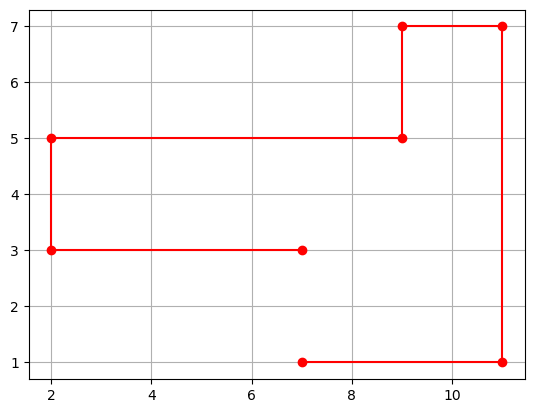

In [1]:
import numpy as np
import matplotlib.pylab as plt

fname=r'C:/Users/mniko/Princeton Dropbox/Milos Nikolic/git/advent-of-code-2025/2025_12_09/test_input.txt'
X=[]
Y=[]
with open(fname) as f:
    for line in f:
        l=line.strip().split(',')
        x,y=[int(val) for val in l]
        X.append(x)
        Y.append(y)

N=len(X)
X=np.array(X,dtype='float64') #master lists of point coordinates.
Y=np.array(Y,dtype='float64')
plt.plot(X,Y,'ro-')
plt.grid(True)
plt.show()

In [56]:
Yunique=np.unique(Y)
print(Yunique)
Xunique=np.unique(X)

[1. 3. 5. 7.]


In [2]:
Ny=len(Yunique)
Nx=len(Xunique)

grid=np.zeros((Ny,Nx))

for i in range(Ny):
    for j in range(Nx):
        idx_y=np.where(Y==Yunique[i]) 
        idx_x= np.where(X == Xunique[j])




NameError: name 'Yunique' is not defined

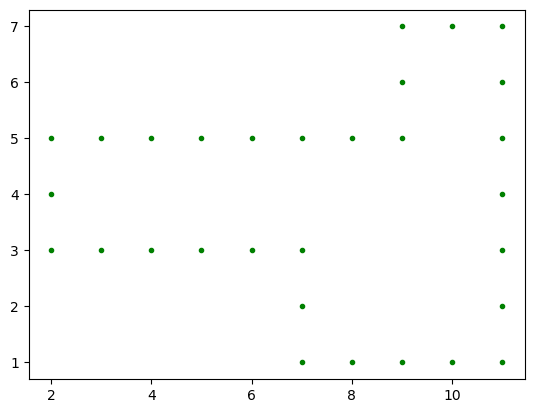

30
8


In [3]:
gX=[]
gY=[]
N=len(X)
for i in range(N):
    point1=(X[i],Y[i])
    if i == (N-1):
        point2=(X[0],Y[0])
    else:
        point2=(X[i+1],Y[i+1])
    
    x1,y1=point1
    x2,y2=point2
    if x1==x2:
        ys=np.arange(y1,y2,np.sign(y2-y1))
        xs=np.full_like(ys,x1)
    elif y1==y2:
        xs=np.arange(x1,x2,np.sign(x2-x1))
        ys=np.full_like(xs,y1)
    else:
        print('points are not aligned')
        print(point1,point2)

    gX.extend(xs)
    gY.extend(ys)

gX=np.array(gX)
gY=np.array(gY)
plt.plot(gX,gY,'g.')
plt.show()
print(len(gX))
print(len(X))
Ng=len(gX)

TraitError: The 'min' trait of an IntSlider instance expected an int, not the function 'update'.

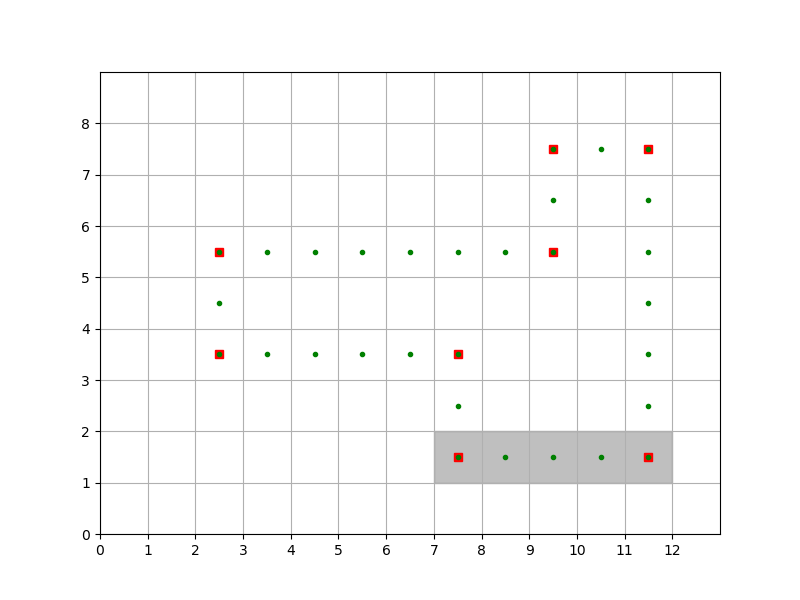

In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation

# --- helper ---
def get_rect(point1, point2):
    x1, y1 = point1
    x2, y2 = point2
    x_BL, y_BL = min(x1, x2), min(y1, y2)
    x_TR, y_TR = max(x1, x2) + 1, max(y1, y2) + 1
    return (x_BL, y_BL), x_TR - x_BL, y_TR - y_BL


# --- figure setup ---
fig, ax = plt.subplots(figsize=(8, 6))

data0, = ax.plot(X + 0.5, Y + 0.5, 'rs')
dataG, = ax.plot(gX+0.5, gY+0.5, 'g.')
pt1, = ax.plot([], [], 'bo')
pt2, = ax.plot([], [], 'bs')

ax.set_xlim(0, max(X) + 2)
ax.set_ylim(0, max(Y) + 2)
ax.set_xticks(np.arange(0, max(X) + 2))
ax.set_yticks(np.arange(0, max(Y) + 2))
ax.grid(True)

rect0 = get_rect((X[0], Y[0]), (X[1], Y[1]))
R = Rectangle(*rect0, color='gray', alpha=0.5)
ax.add_patch(R)

# --- flatten (i, j) loop ---
pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]

final_area = 0


# --- animation update ---
def update(frame):
    i, j = pairs[frame]

    point1 = (X[i], Y[i])
    point2 = (X[j], Y[j])

    x1, y1 = point1
    x2, y2 = point2

    bottom = min(y1, y2)
    top = max(y1, y2) + 1
    left = min(x1, x2)
    right = max(x1, x2) + 1

    pt1.set_data([x1 + 0.5], [y1 + 0.5])
    pt2.set_data([x2 + 0.5], [y2 + 0.5])

    rect = get_rect(point1, point2)
    R.set(xy=rect[0], width=rect[1], height=rect[2])

    isGood = True
    for k in range(Ng):
        gx, gy = gX[k], gY[k]
        if left <= gx <= right and bottom <= gy <= top:
            isGood = False
            break

    if isGood:
        area = (top - bottom) * (right - left)
        if area > final_area:
            final_area = area
        R.set(color='green', alpha=0.5)
    else:
        R.set(color='red', alpha=0.3)

    return pt1, pt2, R


# --- run animation ---
ani = FuncAnimation(
    fig,
    update,
    frames=len(pairs),
    interval=50,
    blit=False,
    repeat=False
)

plt.show()
print("Final area:", final_area)
